In [173]:
import pandas as pd
import matplotlib.pyplot as plt


df = pd.read_csv('OnlineRetail.csv', encoding='ISO-8859-1')
df.head()



,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [174]:
print(f'количество уникальных заказов: {df["InvoiceNo"].nunique()}')
print(f'количество уникальных товаров: {df["StockCode"].nunique()}')
print(f'размер датафрейма: {df.shape}')
print(f'количество уникальных клиентов: {df["CustomerID"].nunique()}')

количество уникальных заказов: 25900
количество уникальных товаров: 4070
размер датафрейма: (541909, 8)
количество уникальных клиентов: 4372


In [175]:
print(f'пропущенных значений в столбце CustomerID: {df["CustomerID"].isna().sum()}')
print(f'пропущенных значений в столбце InvoiceNo: {df["InvoiceNo"].isna().sum()}')
print(f'пропущенных значений в столбце UnitPrice: {df["UnitPrice"].isna().sum()}')

пропущенных значений в столбце CustomerID: 135080
пропущенных значений в столбце InvoiceNo: 0
пропущенных значений в столбце UnitPrice: 0


In [176]:
df_customers = df.dropna(subset=['CustomerID']).copy()
df_customers.shape

(406829, 8)

In [177]:
dublicates = df_customers.duplicated().sum()
print(f'Количество дубликатов в датафрейме: {dublicates}')

df_customers.drop_duplicates(inplace=True)
df_customers.shape

Количество дубликатов в датафрейме: 5225


(401604, 8)

In [178]:
df_customers['CustomerID'] = df_customers['CustomerID'].astype(int)
df_customers['InvoiceDate'] = pd.to_datetime(df_customers['InvoiceDate'])

print(f'строк для анализа клиентов: {df_customers.shape[0]}')
print(f'уникальных клиентов: {df_customers["CustomerID"].nunique()}')

строк для анализа клиентов: 401604
уникальных клиентов: 4372


In [179]:
df_customers['Revenue'] = df_customers['Quantity'] * df_customers['UnitPrice']
df_customers.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


In [180]:
df_valid_items = df_customers[df_customers['Description'].str.isupper() == True].copy()
df_valid_items['Description'] = df_valid_items['Description'].str.strip()


df_sales = df_valid_items[df_valid_items['Quantity'] > 0].copy()
df_returns = df_valid_items[df_valid_items['Quantity'] < 0].copy()


df_sales['Revenue'] = df_sales['Quantity'] * df_sales['UnitPrice']

print(f"Строк с чистыми продажами: {df_sales.shape[0]}")
print(f"Строк с возвратами: {df_returns.shape[0]}")


Строк с чистыми продажами: 391080
Строк с возвратами: 8580


In [181]:
item_total_revenue = df_sales.groupby('Description')['Revenue'].sum()


print("Топ-10 товаров с наименьшей выручкой за весь период:")
print(item_total_revenue.sort_values(ascending=True).head(10))

Топ-10 товаров с наименьшей выручкой за весь период:
Description
PADS TO MATCH ALL CUSHIONS             0.003
HEN HOUSE W CHICK IN NEST              0.420
SET 12 COLOURING PENCILS DOILEY        0.650
VINTAGE BLUE TINSEL REEL               0.840
PINK CRYSTAL GUITAR PHONE CHARM        0.850
PURPLE FRANGIPANI HAIRCLIP             0.850
HAPPY BIRTHDAY CARD TEDDY/CAKE         0.950
CAT WITH SUNGLASSES BLANK CARD         0.950
60 GOLD AND SILVER FAIRY CAKE CASES    1.100
RUBY GLASS CLUSTER EARRINGS            1.250
Name: Revenue, dtype: float64


In [182]:
df_sales.groupby('Description')['UnitPrice'].mean().head()

Description
10 COLOUR SPACEBOY PEN           0.872469
12 COLOURED PARTY BALLOONS       0.662676
12 DAISY PEGS IN WOOD BOX        1.650000
12 EGG HOUSE PAINTED WOOD       12.912656
12 HANGING EGGS HAND PAINTED     2.080000
Name: UnitPrice, dtype: float64

In [183]:
df_sales['Description'] = df_sales['Description'].str.strip()
prices = df_sales[df_sales['Description'] == '4 PURPLE FLOCK DINNER CANDLES']['UnitPrice'].unique()
print(f'уникальные цены на 4 PURPLE FLOCK DINNER CANDLES: {prices}')

уникальные цены на 4 PURPLE FLOCK DINNER CANDLES: [2.55 0.79]


<Axes: title={'center': 'Топ-10 товаров по выручке'}, xlabel='Выручка', ylabel='Товар'>

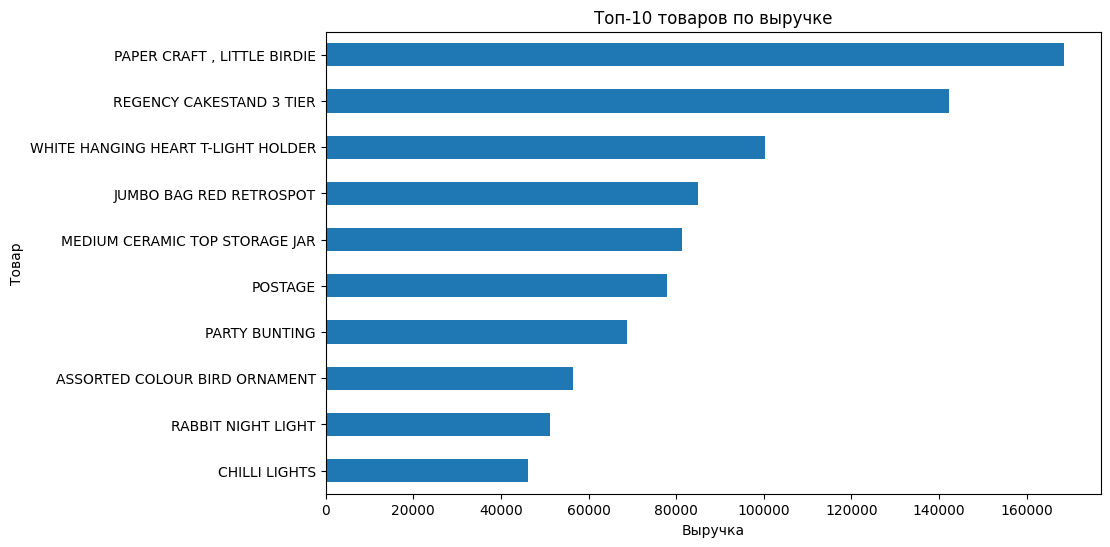

In [184]:
df_sales.groupby('Description')['Revenue'].sum().sort_values(ascending=True)[-10:].plot(kind='barh', figsize=(10, 6), 
                                                                                        title='Топ-10 товаров по выручке', 
                                                                                        xlabel='Выручка', ylabel='Товар')



Country
United Kingdom    347707
Germany             9008
France              8302
EIRE                7202
Spain               2473
Netherlands         2363
Belgium             2022
Switzerland         1839
Portugal            1446
Australia           1184
Name: count, dtype: int64

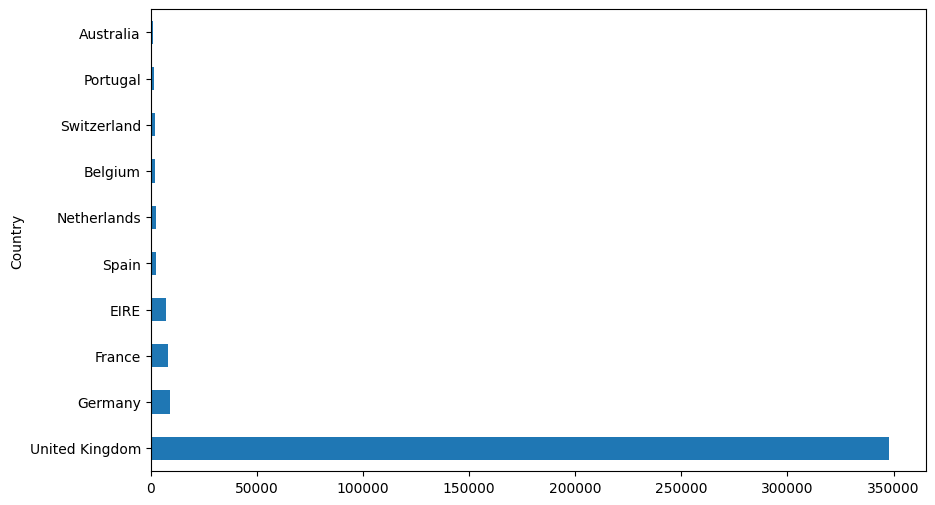

In [185]:
df_sales['Country'].value_counts().head(10).plot(kind='barh', figsize=(10, 6))
df_sales['Country'].value_counts().head(10)

20.845261392494255
Country
Netherlands    120.798282
Australia      116.937340
Japan          116.561900
Sweden          85.656570
Denmark         49.947599
Lithuania       47.458857
Singapore       42.524439
Lebanon         37.641778
EIRE            36.319553
Brazil          35.737500
Name: Revenue, dtype: float64


<Axes: title={'center': 'Средняя выручка по странам'}, xlabel='Средняя выручка', ylabel='Страна'>

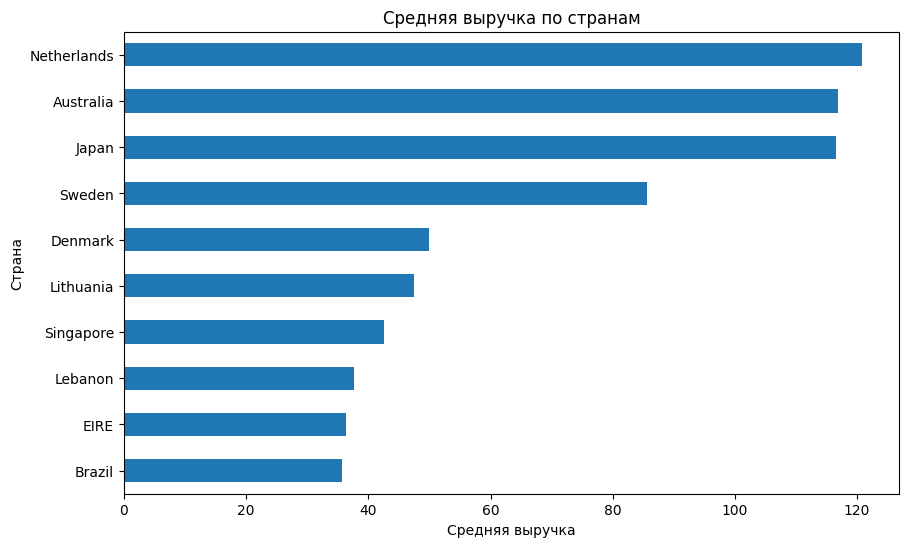

In [186]:
country_revenue = df_sales.groupby('Country')['Revenue'].mean().sort_values(ascending=False).head(10)


print(df_sales[df_sales['Country'] == 'United Kingdom']['Revenue'].mean())
print(country_revenue)

country_revenue.sort_values(ascending=True).plot(kind='barh', figsize=(10, 6), title='Средняя выручка по странам', xlabel='Средняя выручка', ylabel='Страна')

InvoiceMonth
2010-12     569282.500
2011-01     567432.010
2011-02     444637.270
2011-03     588252.390
2011-04     456713.871
2011-05     671695.280
2011-06     657894.290
2011-07     595699.941
2011-08     639866.070
2011-09     945187.421
2011-10    1012474.740
2011-11    1150431.770
2011-12     515872.140
Freq: M, Name: Revenue, dtype: float64


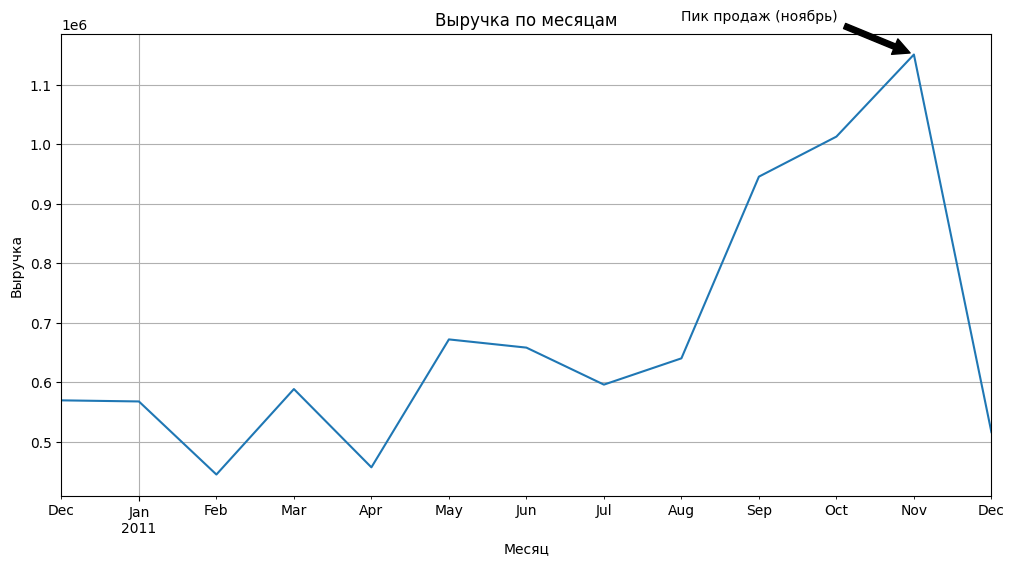

In [187]:
df_sales['InvoiceMonth'] = df_sales['InvoiceDate'].dt.to_period('M')
monthly_revenue = df_sales.groupby('InvoiceMonth')['Revenue'].sum()
print(monthly_revenue)

plt.figure(figsize=(12, 6))
monthly_revenue.plot(kind='line', title='Выручка по месяцам', xlabel='Месяц', ylabel='Выручка')
plt.grid(True)
plt.annotate('Пик продаж (ноябрь)', 
             xy=(pd.Period('2011-11', freq='M'), monthly_revenue.loc['2011-11']), 
             xytext=(pd.Period('2011-08', freq='M'), monthly_revenue.max() * 1.05),
             arrowprops=dict(facecolor='black', shrink=0.05))
plt.show()




In [188]:
customer_revenue = df_sales.groupby('CustomerID')['Revenue'].sum().sort_values(ascending=False).head(10)
total_revenue = df_sales['Revenue'].sum()
customer_revenue_percentage = (customer_revenue / total_revenue) * 100
customer_revenue_percentage = customer_revenue_percentage.head(10)

print(f'Топ-10 клиентов по выручке:\n{customer_revenue}')
print(f'\nОбщая выручка: {total_revenue:.2f}')
print(f'\nДоля выручки от топ-10 клиентов: {customer_revenue_percentage.sum():.2f}%')


Топ-10 клиентов по выручке:
CustomerID
14646    280206.02
18102    259657.30
17450    194338.71
16446    168472.50
14911    140109.33
12415    124914.53
14156    117122.88
17511     90940.66
16029     80850.84
12346     77183.60
Name: Revenue, dtype: float64

Общая выручка: 8815439.69

Доля выручки от топ-10 клиентов: 17.40%
